# S6E9 — Interaction EDA & Synthetic Pattern Discovery

Goal:
Identify nonlinear interactions, conditional target patterns, and
potential synthetic-data artifacts that may improve ROC-AUC beyond
the current LightGBM baseline (~0.94176).

This notebook intentionally does NOT perform expensive model training.

We will investigate:

1. Two-way categorical interactions
2. Numerical × categorical interactions
3. Numerical × numerical relationships
4. Three-way interactions among strong predictors
5. Frequency / combination features
6. Potential synthetic-data artifacts
7. Candidate features for the V2 modeling pipeline

The notebook is designed to run on:
- Local CPU
- Kaggle CPU
- Kaggle GPU

GPU is not required for this notebook because the analysis is
primarily pandas/numpy based.

In [1]:
import os
import gc
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from pathlib import Path

SEED = 42

# ============================================================
# ENVIRONMENT
# ============================================================

IS_KAGGLE = os.path.exists("/kaggle/input")

if IS_KAGGLE:
    DATA_DIR = Path("/kaggle/input/playground-series-s6e9")
else:
    DATA_DIR = Path("./data")

print("Kaggle:", IS_KAGGLE)
print("Data directory:", DATA_DIR)

# ============================================================
# PERFORMANCE
# ============================================================

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

rng = np.random.default_rng(SEED)

Kaggle: False
Data directory: data


In [2]:
def find_file(filename):
    candidates = [
        DATA_DIR / filename,
        Path("/kaggle/input/playground-series-s6e9") / filename,
        Path("/kaggle/input") / filename,
        Path("./data") / filename,
        Path(".") / filename,
    ]

    for path in candidates:
        if path.exists():
            return path

    # Recursive search as fallback
    roots = [
        Path("/kaggle/input") if IS_KAGGLE else Path(".")
    ]

    for root in roots:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]

    raise FileNotFoundError(f"Could not find {filename}")


train_path = r"D:\Programming\kaggle-portfolio\competitions\predicting-electric-vehicle-purchases\data\train.csv"
test_path = r"D:\Programming\kaggle-portfolio\competitions\predicting-electric-vehicle-purchases\data\test.csv"

print("Train:", train_path)
print("Test :", test_path)

Train: D:\Programming\kaggle-portfolio\competitions\predicting-electric-vehicle-purchases\data\train.csv
Test : D:\Programming\kaggle-portfolio\competitions\predicting-electric-vehicle-purchases\data\test.csv


In [3]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head())

Train shape: (668665, 15)
Test shape : (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [4]:
TARGET = "Will_Buy_EV"
ID_COL = "id"

assert TARGET in train.columns
assert TARGET not in test.columns

print("\nTarget distribution:")
print(train[TARGET].value_counts(normalize=True))

print("\nMissing values:")
display(
    train.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

print("\nDuplicate rows:", train.duplicated().sum())


Target distribution:
Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64

Missing values:


,missing
id,0
Age,0
Annual_Income_USD,0
Daily_Commute_km,0
Number_of_Cars_Owned,0
Charging_Stations_Near_Home,0
Charging_Stations_Near_Work,0
Environmental_Concern_Level,0
Gender,0
City_Type,0



Duplicate rows: 0


In [9]:
feature_cols = [
    c for c in train.columns
    if c not in [ID_COL, TARGET, "_target_numeric"]
]

categorical_cols = train[feature_cols].select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = train[feature_cols].select_dtypes(
    include=[np.number]
).columns.tolist()

print("Numerical:")
print(numerical_cols)

print("\nCategorical:")
print(categorical_cols)

Numerical:
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

Categorical:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


In [10]:
# ============================================================
# TARGET RATE ANALYSIS
# ============================================================

# Make sure target is numeric for aggregation
# Yes = 1, No = 0
target_numeric = (
    train[TARGET]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0
    })
)

# Safety check
if target_numeric.isna().any():
    print("Unexpected target values:")
    print(train.loc[target_numeric.isna(), TARGET].value_counts())
    raise ValueError("Target contains values other than Yes/No/1/0.")

train["_target_numeric"] = target_numeric


def target_rate_table(df, col):
    result = (
        df.groupby(col, observed=True)["_target_numeric"]
        .agg(
            mean="mean",
            count="count",
            positive="sum"
        )
        .sort_values("mean", ascending=False)
    )

    result["rate_pct"] = result["mean"] * 100

    return result


for col in categorical_cols:
    print(f"\n{'=' * 70}")
    print(col)
    display(target_rate_table(train, col))


Gender


,mean,count,positive,rate_pct
Gender,,,,
Female,0.177641,295427,52480,17.764118
Other,0.173732,5284,918,17.373202
Male,0.172253,367954,63381,17.225251



City_Type


,mean,count,positive,rate_pct
City_Type,,,,
Rural,0.193389,123983,23977,19.338942
Suburban,0.180936,255377,46207,18.093642
Urban,0.161058,289305,46595,16.105840



Current_Car_Type


...

,mean,count,positive,rate_pct
Home_Charging_Possible,,,,
Yes,0.195819,462677,90601,19.581911
No,0.127085,205988,26178,12.708507



Subsidy_Available


,mean,count,positive,rate_pct
Subsidy_Available,,,,
Yes,0.274695,419909,115347,27.469523
No,0.005757,248756,1432,0.575665



Range_Anxiety_Level


,mean,count,positive,rate_pct
Range_Anxiety_Level,,,,
Low,0.189027,603972,114167,18.902697
Medium,0.041745,62499,2609,4.174467
High,0.001367,2194,3,0.136737


In [11]:
print("TARGET:", TARGET)
print("Target dtype:", train[TARGET].dtype)
print("Target values:")
print(train[TARGET].value_counts())

print("\nCategorical columns:")
print(categorical_cols)

TARGET: Will_Buy_EV
Target dtype: object
Target values:
Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

Categorical columns:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


In [12]:
def smoothed_target_rate(
    df,
    group_cols,
    target=TARGET,
    smoothing=100
):
    global_mean = df[target].mean()

    stats = (
        df.groupby(group_cols, observed=True)[target]
        .agg(["sum", "count"])
        .reset_index()
    )

    stats["smoothed_rate"] = (
        stats["sum"] + smoothing * global_mean
    ) / (
        stats["count"] + smoothing
    )

    stats["rate_pct"] = stats["smoothed_rate"] * 100

    return stats.sort_values(
        "smoothed_rate",
        ascending=False
    )

In [14]:

# ============================================================
# 2-WAY CATEGORICAL INTERACTIONS
# ============================================================

interaction_results = []

for col1, col2 in combinations(categorical_cols, 2):

    stats = (
        train.groupby([col1, col2], observed=True)["_target_numeric"]
        .agg(["mean", "count"])
        .reset_index()
    )

    # Only reasonably populated combinations
    stats = stats[stats["count"] >= 100]

    if len(stats) == 0:
        continue

    interaction_results.append({
        "feature_1": col1,
        "feature_2": col2,
        "n_combinations": len(stats),
        "min_rate": stats["mean"].min(),
        "max_rate": stats["mean"].max(),
        "rate_range": stats["mean"].max() - stats["mean"].min(),
        "weighted_std": np.average(
            np.abs(
                stats["mean"] - train["_target_numeric"].mean()
            ),
            weights=stats["count"]
        )
    })

interaction_results = pd.DataFrame(interaction_results)

interaction_results = interaction_results.sort_values(
    "rate_range",
    ascending=False
).reset_index(drop=True)

display(interaction_results)


,feature_1,feature_2,n_combinations,min_rate,max_rate,rate_range,weighted_std
0,Home_Charging_Possible,Subsidy_Available,4,0.004037,0.303962,0.299925,0.125659
1,Subsidy_Available,Range_Anxiety_Level,6,0.000000,0.295658,0.295658,0.138045
2,City_Type,Subsidy_Available,6,0.005253,0.293148,0.287895,0.125659
3,Current_Car_Type,Subsidy_Available,8,0.005402,0.281331,0.275929,0.125659
4,Gender,Subsidy_Available,6,0.005506,0.278447,0.272941,0.125659
5,City_Type,Range_Anxiety_Level,9,0.000850,0.199134,0.198284,0.025981
6,Current_Car_Type,Range_Anxiety_Level,12,0.000000,0.195452,0.195452,0.026324
7,Home_Charging_Possible,Range_Anxiety_Level,5,0.001367,0.196185,0.194818,0.029735
8,Gender,Range_Anxiety_Level,8,0.000990,0.191579,0.190589,0.025977
9,City_Type,Home_Charging_Possible,6,0.046392,0.200359,0.153967,0.029302


In [15]:
display(
    interaction_results
    .sort_values("rate_range", ascending=False)
    .head(20)
)

,feature_1,feature_2,n_combinations,min_rate,max_rate,rate_range,weighted_std
0,Home_Charging_Possible,Subsidy_Available,4,0.004037,0.303962,0.299925,0.125659
1,Subsidy_Available,Range_Anxiety_Level,6,0.000000,0.295658,0.295658,0.138045
2,City_Type,Subsidy_Available,6,0.005253,0.293148,0.287895,0.125659
3,Current_Car_Type,Subsidy_Available,8,0.005402,0.281331,0.275929,0.125659
4,Gender,Subsidy_Available,6,0.005506,0.278447,0.272941,0.125659
5,City_Type,Range_Anxiety_Level,9,0.000850,0.199134,0.198284,0.025981
6,Current_Car_Type,Range_Anxiety_Level,12,0.000000,0.195452,0.195452,0.026324
7,Home_Charging_Possible,Range_Anxiety_Level,5,0.001367,0.196185,0.194818,0.029735
8,Gender,Range_Anxiety_Level,8,0.000990,0.191579,0.190589,0.025977
9,City_Type,Home_Charging_Possible,6,0.046392,0.200359,0.153967,0.029302


In [18]:
# ============================================================
# INTERACTION EXPLORER
# ============================================================

def show_interaction(col1, col2, min_count=100):

    stats = (
        train.groupby([col1, col2], observed=True)["_target_numeric"]
        .agg(
            target_rate="mean",
            count="count",
            positives="sum"
        )
        .reset_index()
    )

    # Keep sufficiently populated combinations
    stats = stats[stats["count"] >= min_count].copy()

    # Convert target rate to percentage
    stats["target_rate_pct"] = stats["target_rate"] * 100

    # Sort from highest to lowest target rate
    stats = stats.sort_values(
        "target_rate_pct",
        ascending=False
    ).reset_index(drop=True)

    display(stats)

    # Quick summary
    if len(stats) > 0:
        print(f"\nInteraction: {col1} × {col2}")
        print(f"Valid combinations: {len(stats)}")
        print(
            f"Target-rate range: "
            f"{stats['target_rate_pct'].min():.2f}% → "
            f"{stats['target_rate_pct'].max():.2f}%"
        )


In [19]:
show_interaction(
    "Subsidy_Available",
    "Range_Anxiety_Level"
)

,Subsidy_Available,Range_Anxiety_Level,target_rate,count,positives,target_rate_pct
0,Yes,Low,0.295658,381386,112760,29.565847
1,Yes,Medium,0.069433,37216,2584,6.943250
2,No,Low,0.006321,222586,1407,0.632115
3,Yes,High,0.002295,1307,3,0.229533
4,No,Medium,0.000989,25283,25,0.098881
5,No,High,0.000000,887,0,0.000000



Interaction: Subsidy_Available × Range_Anxiety_Level
Valid combinations: 6
Target-rate range: 0.00% → 29.57%


In [20]:
show_interaction(
    "Environmental_Concern_Level",
    "Subsidy_Available"
)

,Environmental_Concern_Level,Subsidy_Available,target_rate,count,positives,target_rate_pct
0,5.0,Yes,0.693279,94669,65632,69.327869
1,4.0,Yes,0.399414,80270,32061,39.941448
2,3.0,Yes,0.186597,74851,13967,18.659737
3,2.0,Yes,0.034780,82317,2863,3.478018
4,5.0,No,0.024756,33567,831,2.475646
5,1.0,Yes,0.009385,87802,824,0.938475
6,4.0,No,0.008088,50199,406,0.808781
7,3.0,No,0.003029,52500,159,0.302857
8,2.0,No,0.000492,52816,26,0.049228
9,1.0,No,0.000168,59674,10,0.016758



Interaction: Environmental_Concern_Level × Subsidy_Available
Valid combinations: 10
Target-rate range: 0.02% → 69.33%


In [21]:
show_interaction(
    "Environmental_Concern_Level",
    "Range_Anxiety_Level"
)

,Environmental_Concern_Level,Range_Anxiety_Level,target_rate,count,positives,target_rate_pct
0,5.0,Low,0.544886,119135,64915,54.488605
1,4.0,Low,0.268310,118445,31780,26.831019
2,5.0,Medium,0.174104,8874,1545,17.410412
3,3.0,Low,0.120400,114784,13820,12.040006
4,4.0,Medium,0.059132,11618,687,5.913238
5,3.0,Medium,0.025229,12129,306,2.522879
6,2.0,Low,0.023523,120478,2834,2.352297
7,5.0,High,0.013216,227,3,1.321586
8,1.0,Low,0.006238,131130,818,0.623808
9,2.0,Medium,0.003888,14146,55,0.388802



Interaction: Environmental_Concern_Level × Range_Anxiety_Level
Valid combinations: 15
Target-rate range: 0.00% → 54.49%


In [28]:
def numerical_target_profile(df, col, q=10):
    temp = df[[col, "_target_numeric"]].dropna().copy()

    temp[f"{col}_bin"] = pd.qcut(
        temp[col],
        q=q,
        duplicates="drop"
    )

    result = (
        temp.groupby(
            f"{col}_bin",
            observed=True
        )["_target_numeric"]
        .agg(["mean", "count"])
        .reset_index()
    )

    result["rate_pct"] = result["mean"] * 100

    return result


Age


,Age_bin,mean,count,rate_pct
0,"(24.999, 29.0]",0.189489,72933,18.948898
1,"(29.0, 34.0]",0.160169,69408,16.016886
2,"(34.0, 38.0]",0.170949,61837,17.094943
3,"(38.0, 43.0]",0.177092,74419,17.709187
4,"(43.0, 47.0]",0.173859,62401,17.385939
5,"(47.0, 51.0]",0.176670,61748,17.666969
6,"(51.0, 56.0]",0.200811,77954,20.081073
7,"(56.0, 60.0]",0.167178,56066,16.717797
8,"(60.0, 65.0]",0.159562,72931,15.956178
9,"(65.0, 69.0]",0.163987,58968,16.398725


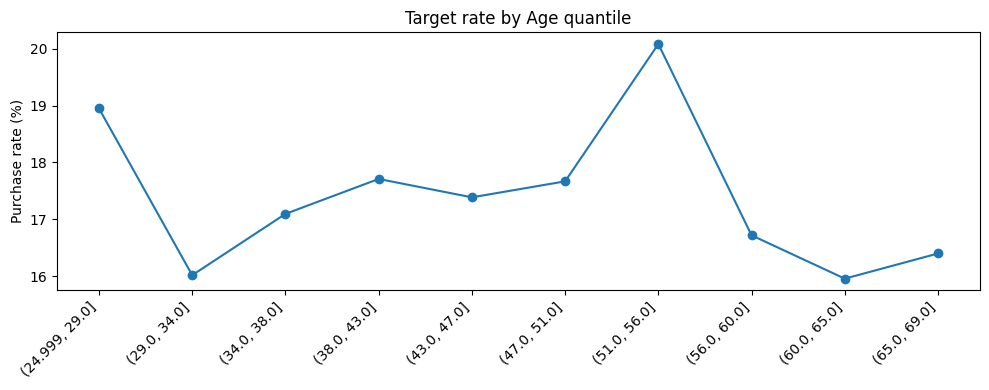


Annual_Income_USD


,Annual_Income_USD_bin,mean,count,rate_pct
0,"(29999.999, 45980.0]",0.044486,66942,4.448627
1,"(45980.0, 62671.0]",0.084593,66861,8.459341
2,"(62671.0, 71832.0]",0.106622,66834,10.662238
3,"(71832.0, 78915.0]",0.131650,66844,13.164981
4,"(78915.0, 84880.0]",0.156083,66977,15.608343
5,"(84880.0, 91619.0]",0.179741,67013,17.974124
6,"(91619.0, 96748.0]",0.197670,66616,19.767023
7,"(96748.0, 107798.0]",0.219553,66854,21.955306
8,"(107798.0, 122349.0]",0.289040,66970,28.903987
9,"(122349.0, 188549.0]",0.337313,66754,33.731312


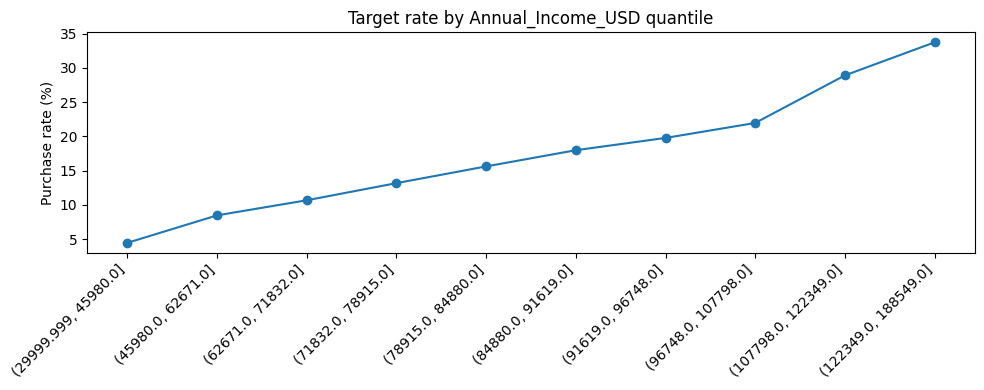


Daily_Commute_km


,Daily_Commute_km_bin,mean,count,rate_pct
0,"(4.999, 21.9]",0.196327,201796,19.632698
1,"(21.9, 28.3]",0.181567,66306,18.156728
2,"(28.3, 33.6]",0.168078,66505,16.807759
3,"(33.6, 39.0]",0.173410,66680,17.341032
4,"(39.0, 44.9]",0.182021,67355,18.202064
5,"(44.9, 49.8]",0.158270,66576,15.827025
6,"(49.8, 55.8]",0.165747,67205,16.574660
7,"(55.8, 98.7]",0.127487,66242,12.748709


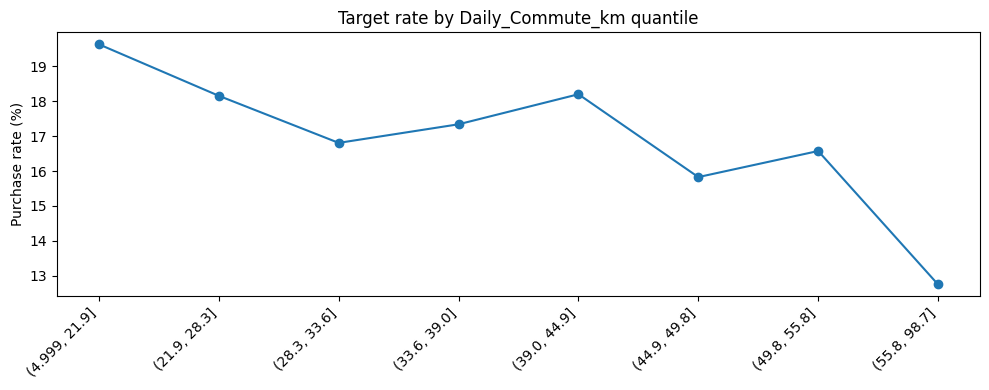


Number_of_Cars_Owned


,Number_of_Cars_Owned_bin,mean,count,rate_pct
0,"(0.999, 2.0]",0.174827,586299,17.482718
1,"(2.0, 3.0]",0.174848,68877,17.484792
2,"(3.0, 4.0]",0.165691,13489,16.569056


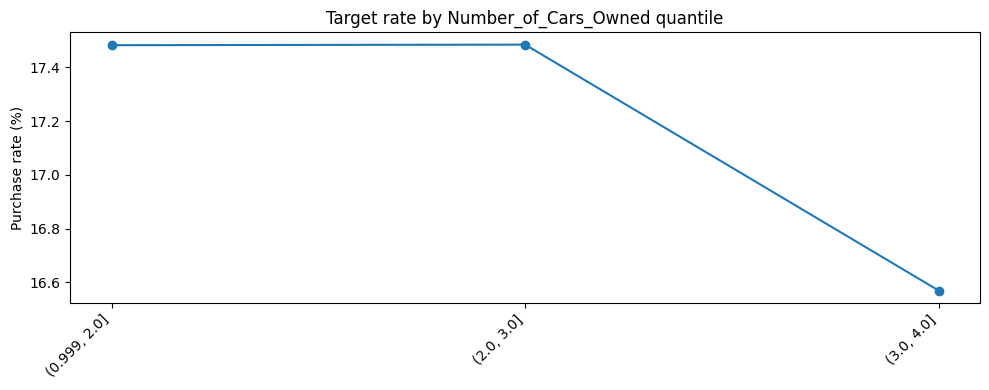


Charging_Stations_Near_Home


,Charging_Stations_Near_Home_bin,mean,count,rate_pct
0,"(-0.001, 1.0]",0.191471,138042,19.147071
1,"(1.0, 2.0]",0.188041,101547,18.804101
2,"(2.0, 3.0]",0.161543,58845,16.154304
3,"(3.0, 4.0]",0.158478,53692,15.847799
4,"(4.0, 5.0]",0.168516,52986,16.851621
5,"(5.0, 7.0]",0.165618,113146,16.561787
6,"(7.0, 8.0]",0.162711,20816,16.271138
7,"(8.0, 11.0]",0.168802,66119,16.880171
8,"(11.0, 14.0]",0.173651,63472,17.365137


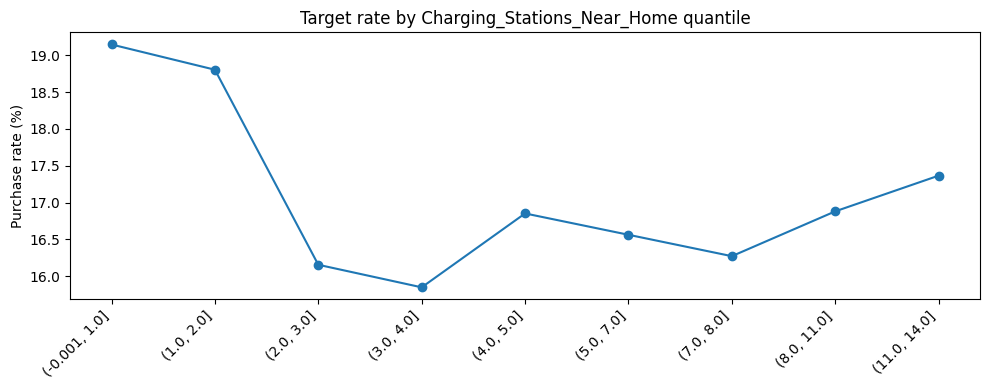


Charging_Stations_Near_Work


,Charging_Stations_Near_Work_bin,mean,count,rate_pct
0,"(-0.001, 1.0]",0.184765,79409,18.476495
1,"(1.0, 3.0]",0.181386,129277,18.138571
2,"(3.0, 5.0]",0.174386,92209,17.438645
3,"(5.0, 6.0]",0.168768,49103,16.876769
4,"(6.0, 8.0]",0.171769,96269,17.176869
5,"(8.0, 9.0]",0.173646,49745,17.364559
6,"(9.0, 12.0]",0.165300,48536,16.529998
7,"(12.0, 16.0]",0.170329,70904,17.032890
8,"(16.0, 19.0]",0.169451,53213,16.945107


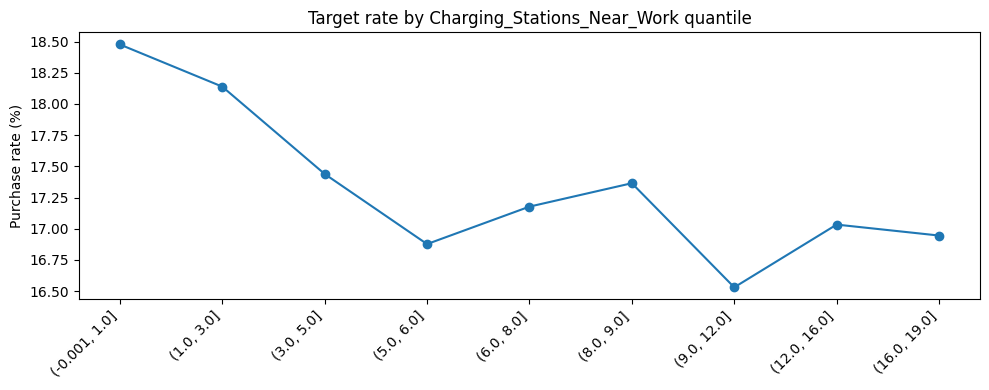


Environmental_Concern_Level


,Environmental_Concern_Level_bin,mean,count,rate_pct
0,"(0.999, 2.0]",0.013174,282609,1.317368
1,"(2.0, 3.0]",0.110922,127351,11.092178
2,"(3.0, 4.0]",0.248848,130469,24.884839
3,"(4.0, 5.0]",0.518287,128236,51.828660


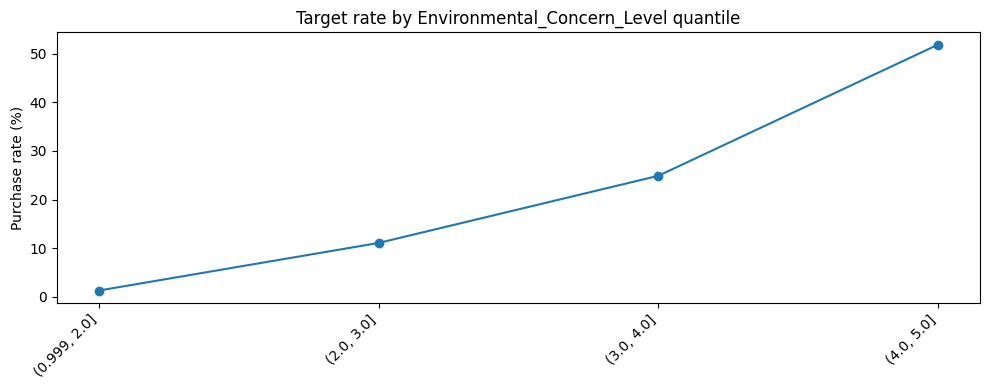

In [29]:
for col in numerical_cols:

    print(f"\n{'=' * 70}")
    print(col)

    profile = numerical_target_profile(train, col)
    display(profile)

    plt.figure(figsize=(10, 4))
    plt.plot(
        range(len(profile)),
        profile["rate_pct"],
        marker="o"
    )
    plt.xticks(
        range(len(profile)),
        [str(x) for x in profile.iloc[:, 0]],
        rotation=45,
        ha="right"
    )
    plt.ylabel("Purchase rate (%)")
    plt.title(f"Target rate by {col} quantile")
    plt.tight_layout()
    plt.show()

In [31]:
num_cat_results = []

for num_col in numerical_cols:
    for cat_col in categorical_cols:

        temp = train[[num_col, cat_col, "_target_numeric"]].copy()

        temp["_bin"] = pd.qcut(
            temp[num_col],
            q=5,
            duplicates="drop"
        )

        stats = (
            temp.groupby(
                ["_bin", cat_col],
                observed=True
            )["_target_numeric"]
            .agg(["mean", "count"])
            .reset_index()
        )

        stats = stats[stats["count"] >= 100]

        if len(stats) == 0:
            continue

        num_cat_results.append({
            "numerical": num_col,
            "categorical": cat_col,
            "min_rate": stats["mean"].min(),
            "max_rate": stats["mean"].max(),
            "rate_range": (
                stats["mean"].max() -
                stats["mean"].min()
            )
        })

num_cat_results = pd.DataFrame(num_cat_results)

display(
    num_cat_results
    .sort_values("rate_range", ascending=False)
    .head(25)
)

,numerical,categorical,min_rate,max_rate,rate_range
40,Environmental_Concern_Level,Subsidy_Available,0.000320,0.693279,0.692959
41,Environmental_Concern_Level,Range_Anxiety_Level,0.000000,0.544886,0.544886
39,Environmental_Concern_Level,Home_Charging_Possible,0.009433,0.553145,0.543712
37,Environmental_Concern_Level,City_Type,0.012019,0.553615,0.541596
38,Environmental_Concern_Level,Current_Car_Type,0.010991,0.525403,0.514412
36,Environmental_Concern_Level,Gender,0.012862,0.523485,0.510624
10,Annual_Income_USD,Subsidy_Available,0.001735,0.455738,0.454003
11,Annual_Income_USD,Range_Anxiety_Level,0.000000,0.334936,0.334936
9,Annual_Income_USD,Home_Charging_Possible,0.043631,0.343664,0.300033
16,Daily_Commute_km,Subsidy_Available,0.004411,0.298621,0.294210


In [32]:
STRONG_CATEGORICALS = [
    "Environmental_Concern_Level",
    "Subsidy_Available",
    "Range_Anxiety_Level",
    "Home_Charging_Possible",
    "City_Type",
    "Current_Car_Type",
]

In [33]:
three_way_results = []

for cols in combinations(STRONG_CATEGORICALS, 3):

    stats = (
        train.groupby(list(cols), observed=True)["_target_numeric"]
        .agg(["mean", "count"])
        .reset_index()
    )

    stats = stats[stats["count"] >= 100]

    if len(stats) == 0:
        continue

    three_way_results.append({
        "features": " × ".join(cols),
        "n_groups": len(stats),
        "min_rate": stats["mean"].min(),
        "max_rate": stats["mean"].max(),
        "rate_range": stats["mean"].max() - stats["mean"].min(),
    })

three_way_results = pd.DataFrame(three_way_results)

display(
    three_way_results
    .sort_values("rate_range", ascending=False)
)

,features,n_groups,min_rate,max_rate,rate_range
1,Environmental_Concern_Level × Subsidy_Availabl...,20,0.000154,0.724374,0.724221
0,Environmental_Concern_Level × Subsidy_Availabl...,30,0.000000,0.718845,0.718845
2,Environmental_Concern_Level × Subsidy_Availabl...,30,0.000088,0.715374,0.715287
3,Environmental_Concern_Level × Subsidy_Availabl...,40,0.000000,0.698394,0.698394
5,Environmental_Concern_Level × Range_Anxiety_Le...,42,0.000000,0.562967,0.562967
7,Environmental_Concern_Level × Home_Charging_Po...,30,0.000000,0.561817,0.561817
9,Environmental_Concern_Level × City_Type × Curr...,60,0.004101,0.562585,0.558485
8,Environmental_Concern_Level × Home_Charging_Po...,40,0.003042,0.559441,0.556398
4,Environmental_Concern_Level × Range_Anxiety_Le...,25,0.000000,0.553756,0.553756
6,Environmental_Concern_Level × Range_Anxiety_Le...,49,0.000000,0.550459,0.550459


In [34]:
frequency_results = []

for col1, col2 in combinations(categorical_cols, 2):

    combo = (
        train.groupby([col1, col2], observed=True)
        .size()
        .reset_index(name="count")
    )

    frequency_results.append({
        "features": f"{col1} × {col2}",
        "n_combinations": len(combo),
        "min_count": combo["count"].min(),
        "median_count": combo["count"].median(),
        "max_count": combo["count"].max()
    })

frequency_results = pd.DataFrame(frequency_results)

display(frequency_results)

,features,n_combinations,min_count,median_count,max_count
0,Gender × City_Type,9,935,67162.0,160653
1,Gender × Current_Car_Type,12,314,28593.0,166491
2,Gender × Home_Charging_Possible,6,1743,102122.5,252781
3,Gender × Subsidy_Available,6,1953,123401.5,230478
4,Gender × Range_Anxiety_Level,9,19,4756.0,331227
5,City_Type × Current_Car_Type,12,7093,39473.0,132263
6,City_Type × Home_Charging_Possible,6,4074,116772.5,229132
7,City_Type × Subsidy_Available,6,43232,102762.0,179081
8,City_Type × Range_Anxiety_Level,9,506,16354.0,246513
9,Current_Car_Type × Home_Charging_Possible,8,13049,66126.0,209188


In [ ]:
def combination_target_stats(col1, col2, min_count=20):

    result = (
        train.groupby([col1, col2], observed=True)["_target_numeric"]
        .agg(["mean", "count"])
        .reset_index()
    )

    result = result[result["count"] >= min_count]

    result["rate_pct"] = result["mean"] * 100

    return result.sort_values(
        "rate_pct",
        ascending=False
    )

In [36]:
combination_target_stats(
    "Subsidy_Available",
    "Range_Anxiety_Level"
)

,Subsidy_Available,Range_Anxiety_Level,mean,count,rate_pct
4,Yes,Low,0.295658,381386,29.565847
5,Yes,Medium,0.069433,37216,6.943250
1,No,Low,0.006321,222586,0.632115
3,Yes,High,0.002295,1307,0.229533
2,No,Medium,0.000989,25283,0.098881
0,No,High,0.000000,887,0.000000


In [37]:
DIGIT_FEATURES = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
]

In [41]:
# ============================================================
# DIGIT / MODULO ARTIFACT INVESTIGATION
# ============================================================

digit_results = []

for col in DIGIT_FEATURES:

    s = train[col]

    for mod in [2, 3, 5, 10, 100]:

        temp = pd.DataFrame({
            "value": s % mod,
            "_target_numeric": train["_target_numeric"]
        })

        stats = (
            temp
            .groupby("value", observed=True)["_target_numeric"]
            .agg(["mean", "count"])
        )

        # Ignore very tiny groups
        stats = stats[stats["count"] >= 100]

        if len(stats) == 0:
            continue

        weighted_rate = np.average(
            stats["mean"],
            weights=stats["count"]
        )

        deviation = np.abs(
            stats["mean"] - train["_target_numeric"].mean()
        ).max()

        digit_results.append({
            "feature": col,
            "operation": f"mod_{mod}",
            "max_deviation": deviation,
            "weighted_rate": weighted_rate,
            "n_groups": len(stats)
        })

digit_results = pd.DataFrame(digit_results)

display(
    digit_results
    .sort_values("max_deviation", ascending=False)
    .reset_index(drop=True)
)

,feature,operation,max_deviation,weighted_rate,n_groups
0,Daily_Commute_km,mod_5,0.235226,0.174624,110
1,Daily_Commute_km,mod_100,0.234941,0.175009,574
2,Daily_Commute_km,mod_10,0.234941,0.174618,186
3,Daily_Commute_km,mod_2,0.189841,0.174649,47
4,Daily_Commute_km,mod_3,0.176190,0.174648,69
5,Annual_Income_USD,mod_100,0.120717,0.174645,100
6,Annual_Income_USD,mod_10,0.052644,0.174645,10
7,Age,mod_100,0.044486,0.174645,45
8,Annual_Income_USD,mod_5,0.028161,0.174645,5
9,Charging_Stations_Near_Home,mod_100,0.023340,0.174645,15


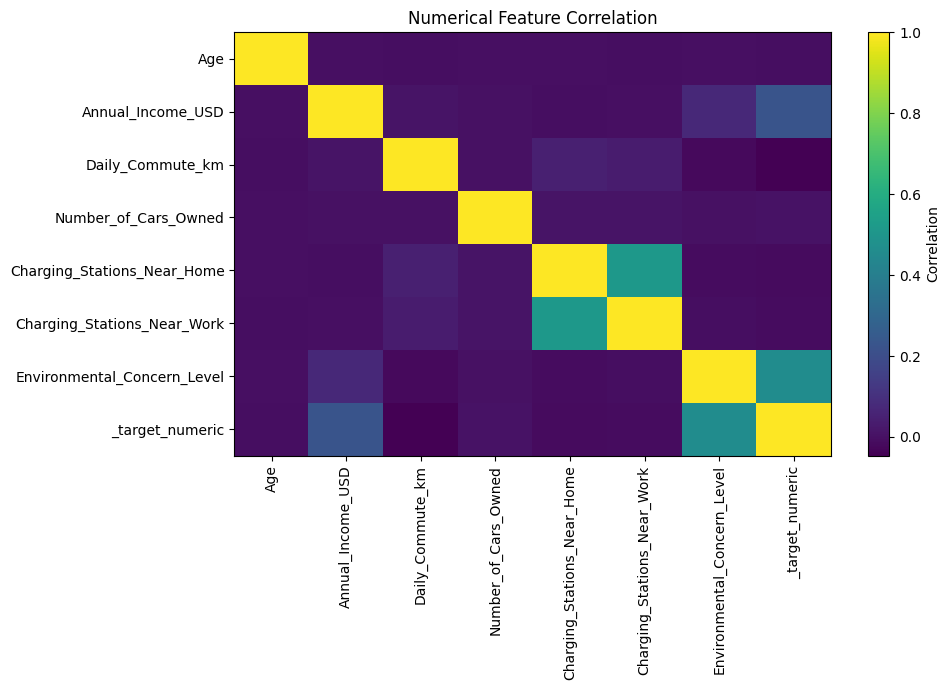

In [42]:
corr = train[numerical_cols + ["_target_numeric"]].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(
    range(len(corr.index)),
    corr.index
)
plt.colorbar(label="Correlation")
plt.title("Numerical Feature Correlation")
plt.tight_layout()
plt.show()

In [44]:
ratio_candidates = pd.DataFrame({
    "income_per_age":
        train["Annual_Income_USD"] /
        (train["Age"] + 1),

    "income_per_commute":
        train["Annual_Income_USD"] /
        (train["Daily_Commute_km"] + 1),

    "stations_total":
        train["Charging_Stations_Near_Home"] +
        train["Charging_Stations_Near_Work"],

    "stations_difference":
        train["Charging_Stations_Near_Work"] -
        train["Charging_Stations_Near_Home"],

    "work_stations_per_commute":
        train["Charging_Stations_Near_Work"] /
        (train["Daily_Commute_km"] + 1),

    "home_stations_per_commute":
        train["Charging_Stations_Near_Home"] /
        (train["Daily_Commute_km"] + 1),
})

ratio_candidates["_target_numeric"] = train["_target_numeric"].values

display(
    ratio_candidates.corr(numeric_only=True)["_target_numeric"]
    .sort_values(ascending=False)
)

_target_numeric              1.000000
income_per_age               0.169066
income_per_commute           0.094079
work_stations_per_commute    0.010095
home_stations_per_commute    0.007671
stations_difference          0.000170
stations_total              -0.016063
Name: _target_numeric, dtype: float64

In [45]:
candidate_features = [
    {
        "feature": "Stations_Total",
        "type": "numeric",
        "reason": "Combined charging infrastructure"
    },
    {
        "feature": "Stations_Difference",
        "type": "numeric",
        "reason": "Home vs work charging asymmetry"
    },
    {
        "feature": "Income_per_Age",
        "type": "numeric",
        "reason": "Economic capacity relative to age"
    },
    {
        "feature": "Income_per_Commute",
        "type": "numeric",
        "reason": "Economic capacity relative to mobility demand"
    },
    {
        "feature": "Subsidy_x_Environmental",
        "type": "interaction",
        "reason": "Strong individual signals may interact"
    },
    {
        "feature": "Subsidy_x_Anxiety",
        "type": "interaction",
        "reason": "Potential policy × adoption barrier interaction"
    },
    {
        "feature": "Environmental_x_Anxiety",
        "type": "interaction",
        "reason": "Potential motivation × barrier interaction"
    },
]

candidate_features = pd.DataFrame(candidate_features)

display(candidate_features)

,feature,type,reason
0,Stations_Total,numeric,Combined charging infrastructure
1,Stations_Difference,numeric,Home vs work charging asymmetry
2,Income_per_Age,numeric,Economic capacity relative to age
3,Income_per_Commute,numeric,Economic capacity relative to mobility demand
4,Subsidy_x_Environmental,interaction,Strong individual signals may interact
5,Subsidy_x_Anxiety,interaction,Potential policy × adoption barrier interaction
6,Environmental_x_Anxiety,interaction,Potential motivation × barrier interaction


In [46]:
OUTPUT_DIR = Path("./eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

interaction_results.to_csv(
    OUTPUT_DIR / "categorical_interactions.csv",
    index=False
)

num_cat_results.to_csv(
    OUTPUT_DIR / "numeric_categorical_interactions.csv",
    index=False
)

three_way_results.to_csv(
    OUTPUT_DIR / "three_way_interactions.csv",
    index=False
)

frequency_results.to_csv(
    OUTPUT_DIR / "combination_frequencies.csv",
    index=False
)

digit_results.to_csv(
    OUTPUT_DIR / "digit_artifacts.csv",
    index=False
)

candidate_features.to_csv(
    OUTPUT_DIR / "candidate_features.csv",
    index=False
)

print(f"Saved analysis results to: {OUTPUT_DIR.resolve()}")

Saved analysis results to: D:\Programming\kaggle-portfolio\competitions\predicting-electric-vehicle-purchases\competition_v2\eda_outputs


In [47]:
display(
    corr.round(3)
)

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,_target_numeric
Age,1.000,-0.005,-0.007,-0.002,-0.004,-0.006,-0.004,-0.007
Annual_Income_USD,-0.005,1.000,0.008,-0.000,-0.009,-0.003,0.076,0.226
Daily_Commute_km,-0.007,0.008,1.000,0.003,0.045,0.035,-0.019,-0.046
Number_of_Cars_Owned,-0.002,-0.000,0.003,1.000,0.008,0.009,-0.001,0.004
Charging_Stations_Near_Home,-0.004,-0.009,0.045,0.008,1.000,0.511,-0.011,-0.016
Charging_Stations_Near_Work,-0.006,-0.003,0.035,0.009,0.511,1.000,-0.008,-0.012
Environmental_Concern_Level,-0.004,0.076,-0.019,-0.001,-0.011,-0.008,1.000,0.464
_target_numeric,-0.007,0.226,-0.046,0.004,-0.016,-0.012,0.464,1.000


In [48]:
display(
    digit_results.sort_values(
        "max_deviation",
        ascending=False
    )
)

,feature,operation,max_deviation,weighted_rate,n_groups
12,Daily_Commute_km,mod_5,0.235226,0.174624,110
14,Daily_Commute_km,mod_100,0.234941,0.175009,574
13,Daily_Commute_km,mod_10,0.234941,0.174618,186
10,Daily_Commute_km,mod_2,0.189841,0.174649,47
11,Daily_Commute_km,mod_3,0.176190,0.174648,69
9,Annual_Income_USD,mod_100,0.120717,0.174645,100
8,Annual_Income_USD,mod_10,0.052644,0.174645,10
4,Age,mod_100,0.044486,0.174645,45
7,Annual_Income_USD,mod_5,0.028161,0.174645,5
24,Charging_Stations_Near_Home,mod_100,0.023340,0.174645,15


In [49]:
display(
    num_cat_results.sort_values(
        "rate_range",
        ascending=False
    )
)

,numerical,categorical,min_rate,max_rate,rate_range
40,Environmental_Concern_Level,Subsidy_Available,0.000320,0.693279,0.692959
41,Environmental_Concern_Level,Range_Anxiety_Level,0.000000,0.544886,0.544886
39,Environmental_Concern_Level,Home_Charging_Possible,0.009433,0.553145,0.543712
37,Environmental_Concern_Level,City_Type,0.012019,0.553615,0.541596
38,Environmental_Concern_Level,Current_Car_Type,0.010991,0.525403,0.514412
36,Environmental_Concern_Level,Gender,0.012862,0.523485,0.510624
10,Annual_Income_USD,Subsidy_Available,0.001735,0.455738,0.454003
11,Annual_Income_USD,Range_Anxiety_Level,0.000000,0.334936,0.334936
9,Annual_Income_USD,Home_Charging_Possible,0.043631,0.343664,0.300033
16,Daily_Commute_km,Subsidy_Available,0.004411,0.298621,0.294210


In [ ]:
# train.drop(columns=["_target_numeric"], inplace=True)